In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

Not all the simulated portfolios are desired. Many have lower returns with the same amount of volatility as others meaning they are inefficient. An efficiency frontier consists of a portfolio that maximises the expected return given a level of volatility.

In [2]:
from src.data_utils import get_simulated_portfolios
import numpy as np
import pandas as pd

# get the simulated portfolio results
simulated_portfolios_df = get_simulated_portfolios()

#sort the portfolio results data frame via volatility
sorted_portfolios_df = simulated_portfolios_df.sort_values("Volatility")

# used to store the most efficient portfolios
efficient_portfolios = []

#set max return as negative infinity
max_return_so_far = -np.inf

for i in range(len(sorted_portfolios_df)):

    #if it is the greatest return we have seen so far we want to keep that portfolio  
    if max_return_so_far < sorted_portfolios_df.iloc[i]["Return"]:

        #adds the portfolio to the row
        efficient_portfolios.append(sorted_portfolios_df.iloc[i])

        #updates so that any portfolios with a lower return than this diserable portfolio is discarded
        max_return_so_far = sorted_portfolios_df.iloc[i]["Return"]

#creates a dataframe of the efficient portfolios
efficient_portfolios_df = pd.DataFrame(efficient_portfolios)

efficient_portfolios_df.head()
efficient_portfolios_df.tail()

[*********************100%***********************]  4 of 4 completed


,Return,Volatility,Apple Weight,Microsoft Weight,Nvidia Weight,S&P500 Weight,Sharpe ratio
2498,0.002382,0.028778,0.040882,0.147271,0.796587,0.015260,0.082784
940,0.002402,0.029143,0.017089,0.137494,0.819266,0.026151,0.082417
117,0.002419,0.029294,0.042956,0.094270,0.829885,0.032889,0.082561
3034,0.002505,0.030390,0.033929,0.066388,0.885177,0.014505,0.082422
8033,0.002585,0.031554,0.021527,0.000480,0.950452,0.027541,0.081925


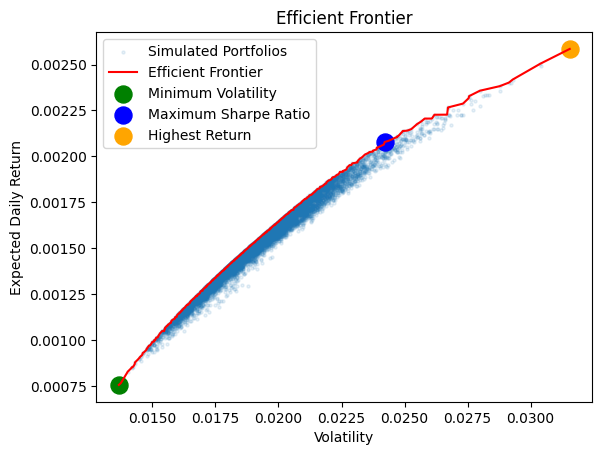

In [3]:
import matplotlib.pyplot as plt

#stores the portfolio with max returns,min volatility and max sharpe ratio
max_return_portfolio = simulated_portfolios_df.loc[simulated_portfolios_df["Return"].idxmax()]
min_volatility_portfolio = simulated_portfolios_df.loc[simulated_portfolios_df["Volatility"].idxmin()]
max_sharpe_ratio_portfolio = simulated_portfolios_df.loc[simulated_portfolios_df["Sharpe ratio"].idxmax()]

#simulated portfolios
plt.scatter(
    sorted_portfolios_df["Volatility"],
    sorted_portfolios_df["Return"],
    s=5,
    alpha=0.1,
    label="Simulated Portfolios"
)

# efficient frontier
plt.plot(
    efficient_portfolios_df["Volatility"],
    efficient_portfolios_df["Return"],
    linewidth=1.5,
    color="red",
    label="Efficient Frontier"
)

#minimum volatility
plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Return"],
    color="green",
    s=150,
    label="Minimum Volatility"
)

#maximum sharpe ratio
plt.scatter(
    max_sharpe_ratio_portfolio["Volatility"],
    max_sharpe_ratio_portfolio["Return"],
    color="blue",
    s=150,
    label="Maximum Sharpe Ratio"
)

#maximum return
plt.scatter(
    max_return_portfolio["Volatility"],
    max_return_portfolio["Return"],
    color="orange",
    s=150,
    label="Highest Return"
)

plt.xlabel("Volatility")
plt.ylabel("Expected Daily Return")
plt.title("Efficient Frontier")
plt.legend()

plt.show()

In [5]:
print("Portfolio with the maximum return")
print(max_return_portfolio)
print("Portfolio with the minimum volatility")
print(min_volatility_portfolio)
print("Portfolio with the maximum sharpe ratio")
print(max_sharpe_ratio_portfolio)

Portfolio with the maximum return
Return              0.002585
Volatility          0.031554
Apple Weight        0.021527
Microsoft Weight    0.000480
Nvidia Weight       0.950452
S&P500 Weight       0.027541
Sharpe ratio        0.081925
Name: 8033, dtype: float64
Portfolio with the minimum volatility
Return              0.000756
Volatility          0.013665
Apple Weight        0.047623
Microsoft Weight    0.001367
Nvidia Weight       0.025728
S&P500 Weight       0.925281
Sharpe ratio        0.055305
Name: 4543, dtype: float64
Portfolio with the maximum sharpe ratio
Return              0.002078
Volatility          0.024212
Apple Weight        0.447345
Microsoft Weight    0.037421
Nvidia Weight       0.508257
S&P500 Weight       0.006977
Sharpe ratio        0.085837
Name: 9838, dtype: float64


From this result you can see that the portfolio with the highest return has most of its weight in Nvidia as it has the highest mean return out of the 4 assets. However this also increases the volatility cause Nvidia also has the highest volatility out of the 4 assets aswell. You can also see the portfolio with the lowest volatility has most of its weight in the S&P500 as the S&P500 has the lowest volatility out of the 4 assests but this comes with lower returns due to the S&P500 having the lowest mean return. The portfolio with the highest sharpe ratio is the best risk adjusted portfolio.